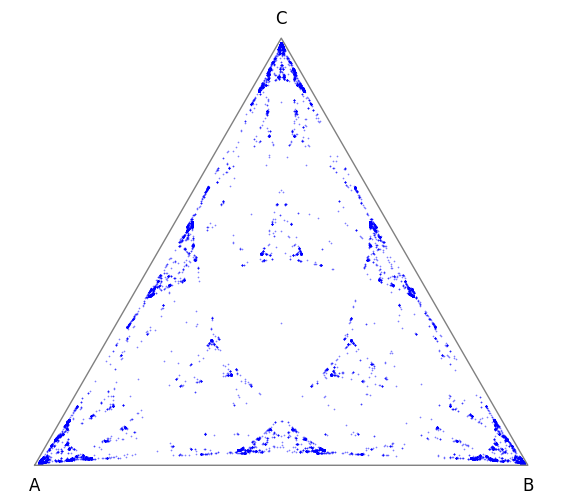

In [ ]:
# Mess3 as an input-conditioned transducer, and its mixed-state presentation.
# Runs as-is in Google Colab (needs only numpy + matplotlib).

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# ---------------------------------------------------------------------------
# 1) Mess3 transducer: labeled matrices T^(y|x) for inputs x in {0, 1}.
#    Mess3's usual parameters are (alpha, x); to avoid clashing with the
#    input symbol x, the second parameter is called m here.
# ---------------------------------------------------------------------------

def mess3_matrices(alpha, m):
    """[T0, T1, T2] with T[y][i, j] = P(next state j, output y | state i)."""
    b = (1 - alpha) / 2
    g = 1 - 2 * m
    T0 = np.array([[alpha * g, b * m,     b * m    ],
                   [alpha * m, b * g,     b * m    ],
                   [alpha * m, b * m,     b * g    ]])
    T1 = np.array([[b * g,     alpha * m, b * m    ],
                   [b * m,     alpha * g, b * m    ],
                   [b * m,     alpha * m, b * g    ]])
    T2 = np.array([[b * g,     b * m,     alpha * m],
                   [b * m,     b * g,     alpha * m],
                   [b * m,     b * m,     alpha * g]])
    return [T0, T1, T2]

PARAMS = {0: dict(alpha=0.85, m=0.05),   # input 0: classic fractal regime
          1: dict(alpha=0.50, m=0.15)}   # input 1: noisier, faster mixing

# T_hat[(y, x)] acts on belief column vectors |rho>
T_hat = {(y, x): Ty.T
         for x in PARAMS
         for y, Ty in enumerate(mess3_matrices(**PARAMS[x]))}

# ---------------------------------------------------------------------------
# 2) Generate a length-L word: inputs X from a biased coin, outputs Y
# ---------------------------------------------------------------------------

def generate_word(L, p0=0.5):
    """X ~ iid coin with P(x=0) = p0; Y sampled from the transducer."""
    X = (rng.random(L) >= p0).astype(int)
    Y = np.empty(L, dtype=int)
    s = rng.integers(3)                       # hidden state
    for t in range(L):
        Ts = mess3_matrices(**PARAMS[X[t]])
        joint = np.array([T[s] for T in Ts])  # rows: y, cols: next state
        k = rng.choice(9, p=joint.ravel() / joint.sum())
        Y[t], s = divmod(k, 3)
    return X, Y

# ---------------------------------------------------------------------------
# 3) MSP: belief states via |rho_{t+1}> = T^(y_t|x_t)|rho_t> / norm
# ---------------------------------------------------------------------------

#EXERCISE 1: Produce the MSP for a L=50,000 sequence for three different input
#probabilities

#Note: The MSP must be a length-L array of length-3 arrays that each encode
#latent distribution

def MSP(X, Y):
    rho = np.array([1/3, 1/3, 1/3]) # start with uniform probability dist
                                    # over possible states
    beliefs = [rho]
    for x, y in zip(X, Y):
        rho = T_hat[(y, x)] @ rho # Computing new beliefs in succession
                                  # Exactly like your written exercises
        rho = rho / rho.sum()
        beliefs.append(rho)
    return beliefs

# ---------------------------------------------------------------------------
# 4) Plot a list of 3-element beliefs in the simplex over states A, B, C
# ---------------------------------------------------------------------------

def plot_beliefs(beliefs):
    """beliefs: a sequence of 3-element lists/arrays summing to 1."""
    verts = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])  # A, B, C
    pts = np.asarray(beliefs) @ verts
    fig, ax = plt.subplots(figsize=(7, 6.5))
    tri = np.vstack([verts, verts[0]])
    ax.plot(tri[:, 0], tri[:, 1], color="gray", lw=1)
    for (vx, vy), name in zip(verts, "ABC"):
        ax.text(vx, vy - 0.04 if vy == 0 else vy + 0.04, name,
                ha="center", va="center", fontsize=12)
    ax.scatter(pts[:, 0], pts[:, 1], s=1.5, lw=0, color="blue", alpha=0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------

#EXERCISE 2: Plot all three MSPs

L = 50000 # Setting L as per the exercise
p0 = 1 # Can play around with this
X, Y = generate_word(L, p0) # Generate a word of length L for some choice of p0
beliefs = MSP(X, Y) # Compute the beliefs for the given word (Y|X)
plot_beliefs(beliefs) # Plot the computed beliefs

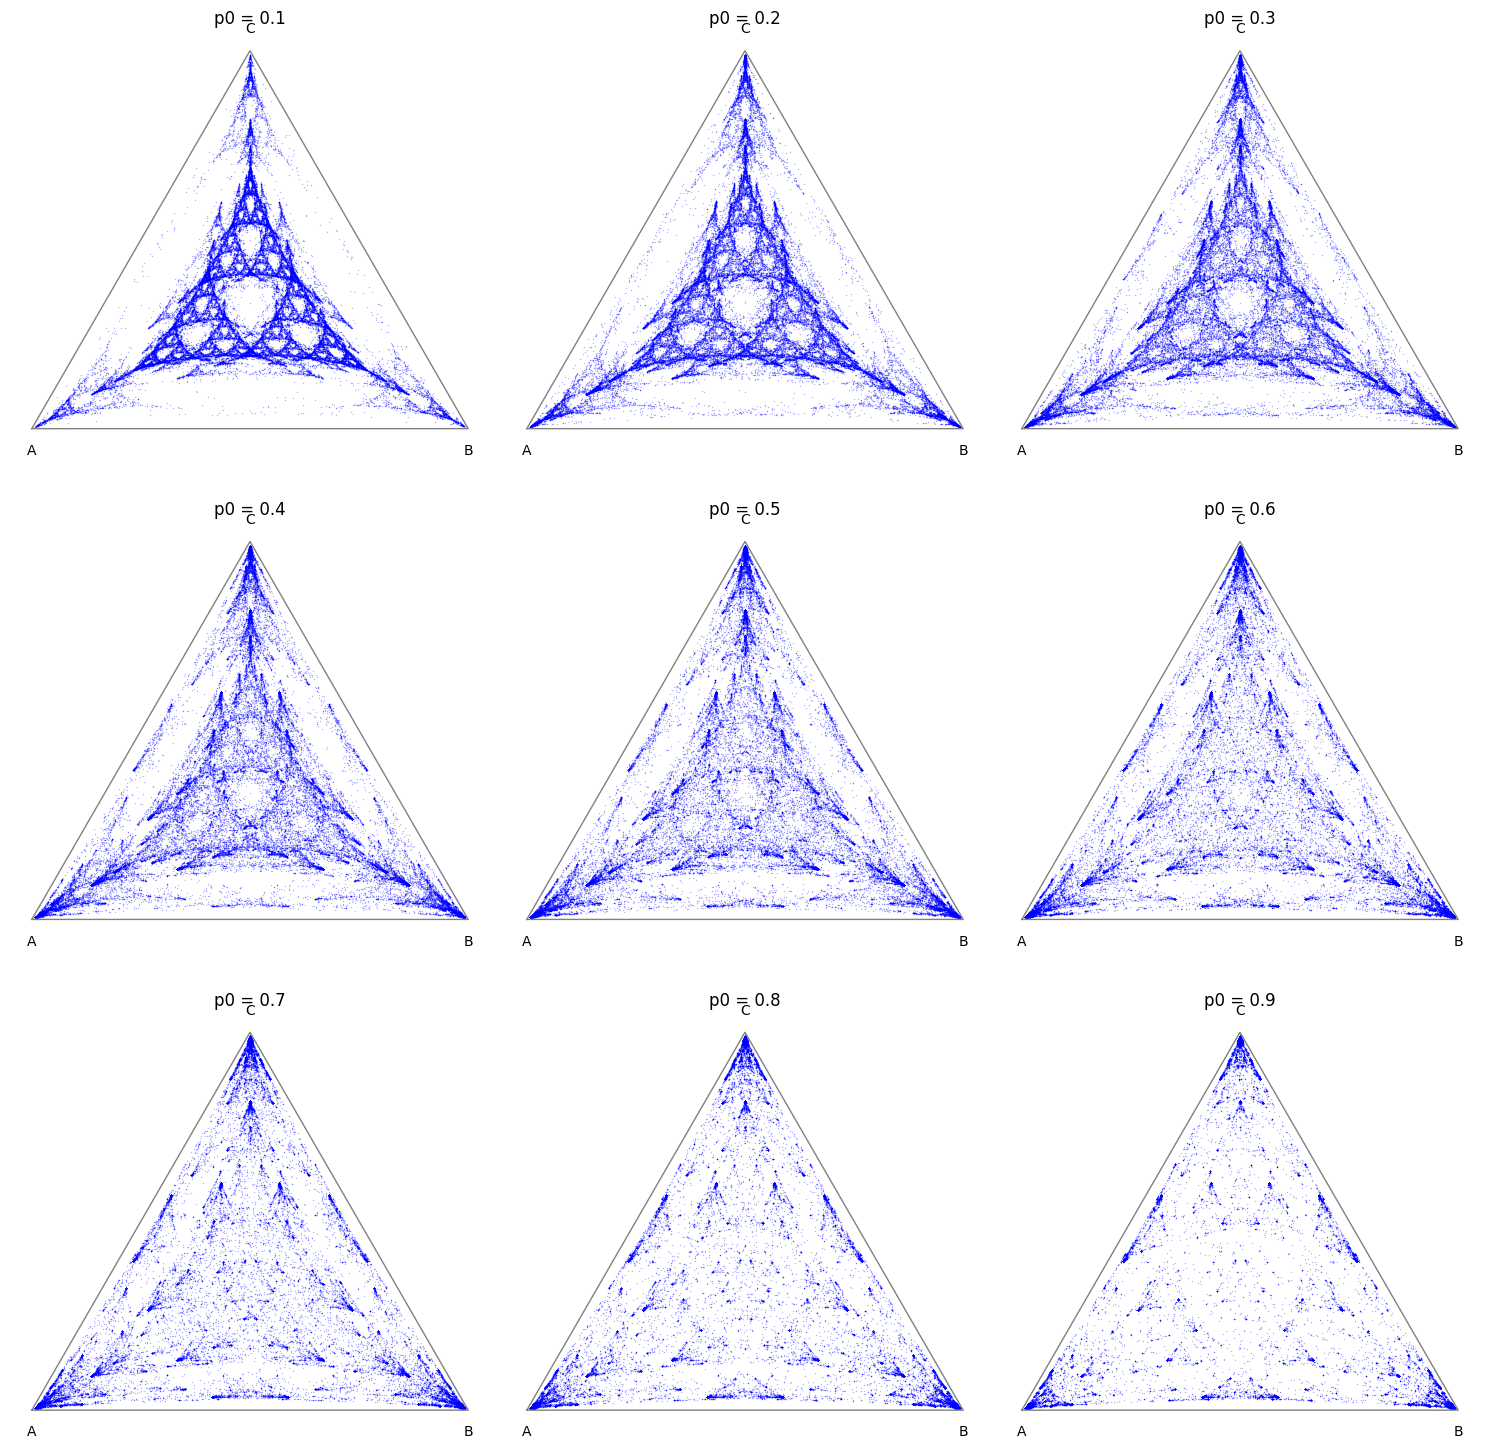

In [ ]:
L = 50000
probabilities = np.arange(0.1, 1.0, 0.1)

# Create a 3x3 grid of subplots for the intermediate probabilities
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

verts = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])  # A, B, C vertices
tri = np.vstack([verts, verts[0]])

for i, p0 in enumerate(probabilities):
    X, Y = generate_word(L, p0)
    beliefs = MSP(X, Y)
    pts = np.asarray(beliefs) @ verts

    ax = axes[i]

    # Draw simplex boundary
    ax.plot(tri[:, 0], tri[:, 1], color="gray", lw=1)

    # Add vertex labels
    for (vx, vy), name in zip(verts, "ABC"):
        ax.text(vx, vy - 0.05 if vy == 0 else vy + 0.05, name,
                ha="center", va="center", fontsize=10)

    # Plot belief points
    ax.scatter(pts[:, 0], pts[:, 1], s=1.0, lw=0, color="blue", alpha=0.3)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"p0 = {p0:.1f}", fontsize=12)

plt.tight_layout()
plt.show()

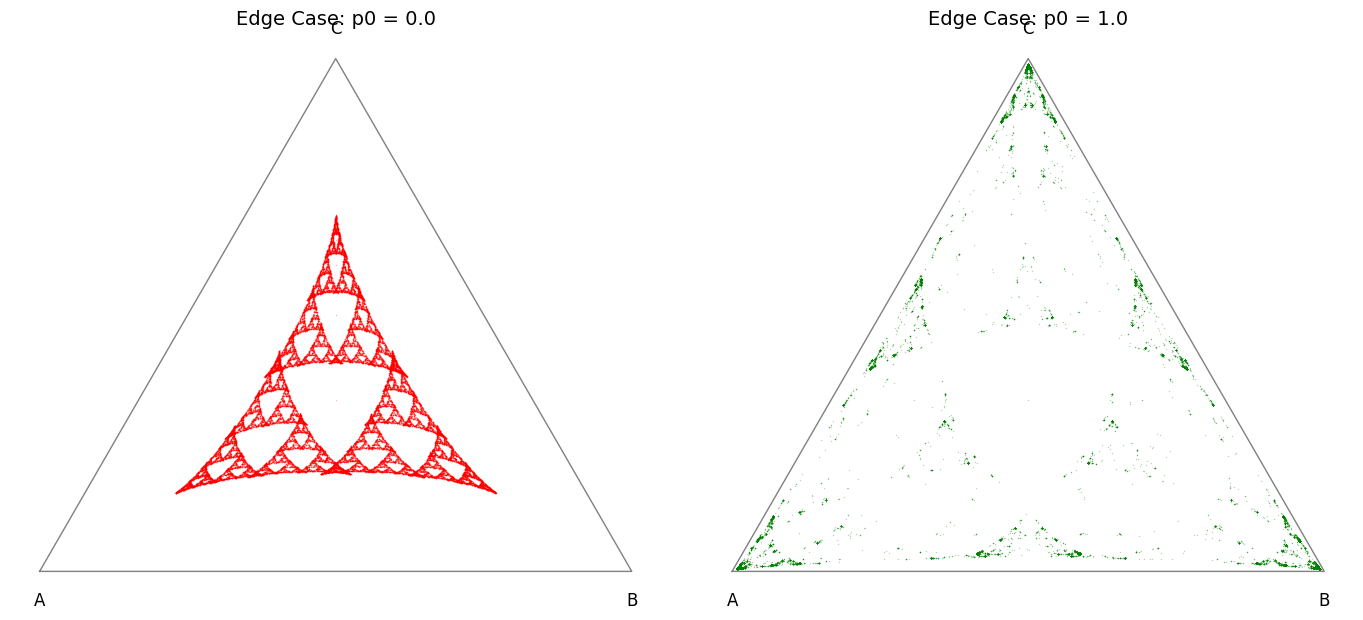

In [ ]:
# Plot the edge cases: p0 = 0 and p0 = 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

edge_cases = [0.0, 1.0]
verts = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])  # A, B, C vertices
tri = np.vstack([verts, verts[0]])

for i, p0 in enumerate(edge_cases):
    X, Y = generate_word(L, p0)
    beliefs = MSP(X, Y)
    pts = np.asarray(beliefs) @ verts

    ax = axes[i]
    ax.plot(tri[:, 0], tri[:, 1], color="gray", lw=1)

    for (vx, vy), name in zip(verts, "ABC"):
        ax.text(vx, vy - 0.05 if vy == 0 else vy + 0.05, name,
                ha="center", va="center", fontsize=12)

    ax.scatter(pts[:, 0], pts[:, 1], s=1.0, lw=0, color="red" if p0==0 else "green", alpha=0.3)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"Edge Case: p0 = {p0:.1f}", fontsize=14)

plt.tight_layout()
plt.show()

### Discussion of Edge Cases

- **Edge Case $p_0 = 0.0$ (Input 1 only):**
  When $p_0 = 0$, the transducer is fed only with the input sequence $x = 1$. The transition matrices associated with $x = 1$ have a relatively low $\alpha = 0.50$ and a higher leak parameter $m = 0.15$. Because of this higher entropy, state transitions are noisier, and the mixing rate is much faster. In the simplex plot, we observe a diffuse, highly-spread point cloud with little to no clear fractal boundary. This represents a chaotic, high-entropy regime where beliefs rapidly spread across the entire inner state space.

- **Edge Case $p_0 = 1.0$ (Input 0 only):**
  When $p_0 = 1$, the transducer only receives input $x = 0$. The parameters for $x = 0$ are $\alpha = 0.85$ (highly self-consistent state transitions) and $m = 0.05$ (very low leakage/noise). This allows the system to converge onto a highly structured, self-similar fractal attractor (the classic Sierpiński-like structure). The system's history is preserved cleanly in its geometric coordinates, showcasing a low-entropy, highly structured regime.